Using device: cuda
Using default parameters: input_dim=60. Set to 129 if using paper's features.
Model loaded from britd_model.pth
Input dimension: 60


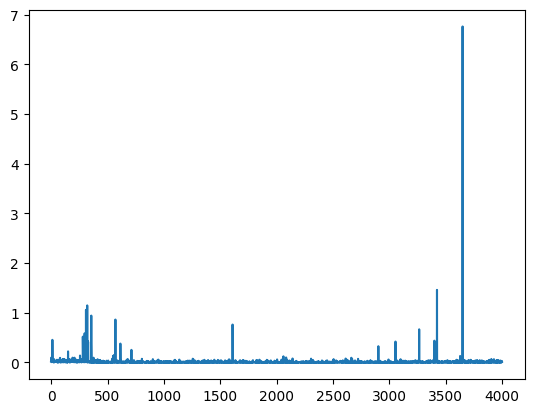


Detected 23 anomalies with threshold 0.2516
Anomalies (index, user_id):
Index 11: User SDH2394
Index 281: User CAG2442
Index 282: User WSA1765
Index 294: User IKP1047
Index 295: User CAM3050

Example anomaly (Index 11, User SDH2394):
Input (first 5 features): tensor([-0.0129, -0.5608, -0.3090, -0.2723, -0.0117], device='cuda:0')
Output (first 5 features): tensor([ 0.0823, -0.6460, -0.3156, -0.3448, -0.0925], device='cuda:0')


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
import pickle

# Model classes (required because britd_model.pth contains only weights)
# These match the BRITD model: 3 BiLSTM layers in encoder, FNN decoder
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, latent_dim):
        super(Encoder, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        latent = self.fc(torch.mean(lstm_out, dim=1))
        return latent

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, seq_len):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        self.output_dim = output_dim
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim * seq_len)
        )

    def forward(self, x):
        reconstructed = self.fc(x)
        reconstructed = reconstructed.view(-1, self.seq_len, self.output_dim)
        return reconstructed

class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Preprocess new data
def preprocess_new_data(csv_files, expected_input_dim):
    try:
        dataframes = [pd.read_csv(file, index_col='Unnamed: 0') for file in csv_files]
    except FileNotFoundError as e:
        raise FileNotFoundError(f"CSV file not found: {e}")

    common_index = dataframes[0].index
    for df in dataframes[1:]:
        common_index = common_index.intersection(df.index)
    if len(common_index) == 0:
        raise ValueError("No common indices found across CSV files.")
    dataframes = [df.loc[common_index] for df in dataframes]

    data = np.stack([df.values for df in dataframes], axis=1)
    actual_input_dim = data.shape[-1]
    if actual_input_dim != expected_input_dim:
        raise ValueError(f"Input dimension mismatch: got {actual_input_dim}, expected {expected_input_dim}")
    print(f"Input dimension: {actual_input_dim}")

    data = np.nan_to_num(data, nan=0.0)

    file = open("scaler.pkl", "rb")
    scaler = pickle.load(file)
    data_reshaped = data.reshape(-1, data.shape[-1])
    data_normalized = scaler.fit_transform(data_reshaped).reshape(data.shape)
    #print("Warning: No scaler.pkl. Fitted new scaler on test data (may affect accuracy).")

    return data_normalized, common_index

# Evaluate reconstruction errors
def evaluate_autoencoder(model, data_tensor, criterion, device):
    model.eval()
    reconstruction_errors = []
    with torch.no_grad():
        for i in range(len(data_tensor)):
            input_data = data_tensor[i:i+1].to(device)
            output = model(input_data)
            error = criterion(output, input_data).item()
            reconstruction_errors.append(error)
    return reconstruction_errors

# Detect anomalies
def detect_anomalies(reconstruction_errors, common_index, threshold=None):
    if threshold is None:
        threshold = np.mean(reconstruction_errors) + 2 * np.std(reconstruction_errors)
    anomalies = [(i, common_index[i]) for i, error in enumerate(reconstruction_errors) if error > threshold]
    return anomalies, threshold

# Main function
def main():
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Model path
    model_path = "britd_model.pth"

    # Model parameters (defaults from paper, no metadata.pkl)
    input_dim = 60  # Change to 129 if model was trained with paper's features
    seq_len = 4
    hidden_dim = 64
    num_layers = 3
    latent_dim = 32
    print(f"Using default parameters: input_dim={input_dim}. Set to 129 if using paper's features.")

    # Initialize model
    encoder = Encoder(input_dim, hidden_dim, num_layers, latent_dim)
    decoder = Decoder(latent_dim, input_dim, seq_len)
    autoencoder = Autoencoder(encoder, decoder).to(device)

    # Load model state
    try:
        autoencoder.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Model loaded from {model_path}")
    except FileNotFoundError:
        raise FileNotFoundError(f"Model file not found at {model_path}")
    except Exception as e:
        raise RuntimeError(f"Failed to load model: {e}. Try input_dim=129 or check architecture.")

    # New data
    csv_files = [
        "gran/0_6_token_counts.csv",
        "gran/6_12_token_counts.csv",
        "gran/12_18_token_counts.csv",
        "gran/18_24_token_counts.csv"
    ]

    # Preprocess data
    data_normalized, common_index = preprocess_new_data(csv_files, input_dim)
    data_tensor = torch.tensor(data_normalized, dtype=torch.float32)

    # Loss function
    criterion = nn.MSELoss()

    # Compute reconstruction errors
    reconstruction_errors = evaluate_autoencoder(autoencoder, data_tensor, criterion, device)
    plt.plot(reconstruction_errors)
    plt.show()

    # Detect anomalies
    anomalies, threshold = detect_anomalies(reconstruction_errors, common_index)
    print(f"\nDetected {len(anomalies)} anomalies with threshold {threshold:.4f}")
    if anomalies:
        print("Anomalies (index, user_id):")
        for idx, user_id in anomalies[:5]:
            print(f"Index {idx}: User {user_id}")
    else:
        print("No anomalies detected.")

    # Inspect a sample
    if anomalies:
        sample_idx = anomalies[0][0]
        autoencoder.eval()
        with torch.no_grad():
            input_sample = data_tensor[sample_idx:sample_idx+1].to(device)
            reconstructed = autoencoder(input_sample)
            print(f"\nExample anomaly (Index {sample_idx}, User {common_index[sample_idx]}):")
            print(f"Input (first 5 features): {input_sample[0, 0, :5]}")
            print(f"Output (first 5 features): {reconstructed[0, 0, :5]}")

if __name__ == "__main__":
    main()